In [1]:
import torch
import matplotlib.pyplot as plt
import math
import scipy.io
import numpy as np
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ─── Parameters ────────────────────────────────────────────────
dt = 1e-2             # Time step
num_steps = 650           # Total steps
T = num_steps * dt          # Total time
num_particles = 1*10**7       # Reduced for performance
small_region_radius = 0.1  # Increased radius

mat = scipy.io.loadmat('data/initialData.mat')['initialData']
small_region_centers = torch.tensor(mat, dtype=torch.float32, device=device)

In [3]:
print(T)

6.5


In [4]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
std0 = 0.3
weightsX0 = torch.tensor([1.0], device=device)
mu_X0 = torch.tensor([[2., 2.]], device=device)
covariances_X0 = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf = torch.tensor([2.0], device=device)
mu_Xinf = torch.tensor([[0.,0.]], device=device)
std0 = 2.0
covariances_Xinf = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── Precompute Cholesky (on CPU → move to device) ─────────────
scale_tril_0 = torch.linalg.cholesky(covariances_X0.cpu())
scale_tril_0 = scale_tril_0.to(device)

scale_tril_T = torch.linalg.cholesky(covariances_Xinf.cpu())
scale_tril_T = scale_tril_T.to(device)

# Precompute inverses of final covariances
inv_covariances_T = torch.linalg.inv(covariances_Xinf)

# Precompute determinants of final covariances (on CPU → move)
det_T = torch.det(covariances_Xinf.cpu()).to(device)

In [5]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [6]:

# Check if there are particles inside the small regions 
for center in range(small_region_centers.shape[0]):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks = distances < small_region_radius
    num_selected = masks.sum().item()
    if num_selected == 0:
        raise ValueError("No particles in the small region. Increase radius or particle count.")
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
initial_positions = positions.clone().cpu().numpy()

Number of particles in small region: 102097
Number of particles in small region: 326853
Number of particles in small region: 310853
Number of particles in small region: 306127
Number of particles in small region: 539693
Number of particles in small region: 473649
Number of particles in small region: 145919
Number of particles in small region: 131580
Number of particles in small region: 80153


In [7]:
positions1 = positions.clone()
small_region_centers1 = small_region_centers.clone()

In [8]:
simParams = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, 1, False, small_region_radius, 'AngeloScore')

In [9]:
final_positions1, avg_paths1, particlesPerCircle1 = doSimulation(positions1, small_region_centers1, simParams, device)

Angelo's algorithm is running...
t = 0.0000  |  Max drift: 1.0955  |  Mean drift: 0.7111
t = 0.5000  |  Max drift: 1.8720  |  Mean drift: 0.6744
t = 1.0000  |  Max drift: 2.2672  |  Mean drift: 0.6535
t = 1.5000  |  Max drift: 2.6204  |  Mean drift: 0.6423
t = 2.0000  |  Max drift: 2.4613  |  Mean drift: 0.6363
t = 2.5000  |  Max drift: 2.6776  |  Mean drift: 0.6329
t = 3.0000  |  Max drift: 2.7431  |  Mean drift: 0.6308
t = 3.5000  |  Max drift: 2.6659  |  Mean drift: 0.6294
t = 4.0000  |  Max drift: 2.7279  |  Mean drift: 0.6286
t = 4.5000  |  Max drift: 2.7669  |  Mean drift: 0.6282
t = 5.0000  |  Max drift: 2.9366  |  Mean drift: 0.6279
t = 5.5000  |  Max drift: 3.1588  |  Mean drift: 0.6275
t = 6.0000  |  Max drift: 2.9048  |  Mean drift: 0.6274


In [10]:
scipy.io.savemat("data/avgPathsAngelo.mat", {"avg_paths": avg_paths1, "final_positions": final_positions1, "particlesPerCircle": particlesPerCircle1, "initial_positions": initial_positions})

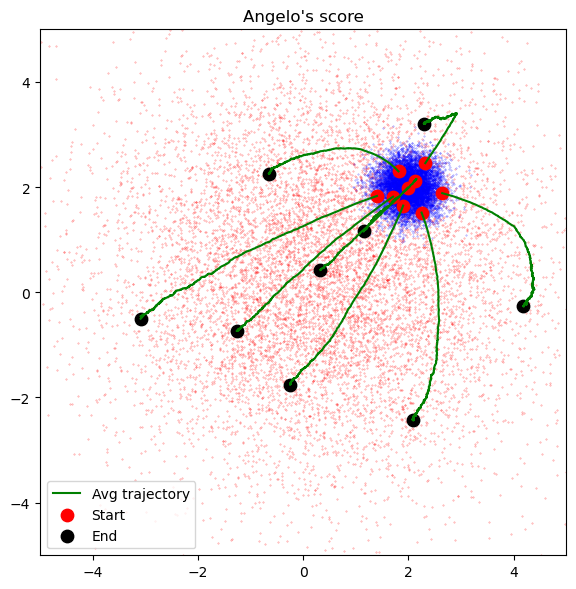

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

# Trajectory
axes.scatter(final_positions1[:10000,0], final_positions1[:10000,1], s=0.1, alpha=0.5, color='red')
axes.scatter(initial_positions[:10000,0], initial_positions[:10000:,1], s=0.1, alpha=0.5, color='blue')
for center in range(small_region_centers.shape[0]):
    axes.plot(avg_paths1[:, center, 0], avg_paths1[:, center, 1], 'g-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes.scatter(avg_paths1[0, center, 0], avg_paths1[0, center, 1], color='red', s=80, label='Start'  if center == 0 else None)
    axes.scatter(avg_paths1[-1, center, 0], avg_paths1[-1, center, 1], color='black', s=80, label='End'  if center == 0 else None)
axes.set_title("Angelo's score")
axes.legend()
axes.set_aspect('equal', adjustable='box')
axes.set_xlim(-5., 5.)
axes.set_ylim(-5., 5.)

plt.savefig("BasicGaussianTransport.pdf")
plt.tight_layout()
plt.show()

In [12]:
particlesPerCircleNormalized1 = particlesPerCircle1 / particlesPerCircle1[0, :]

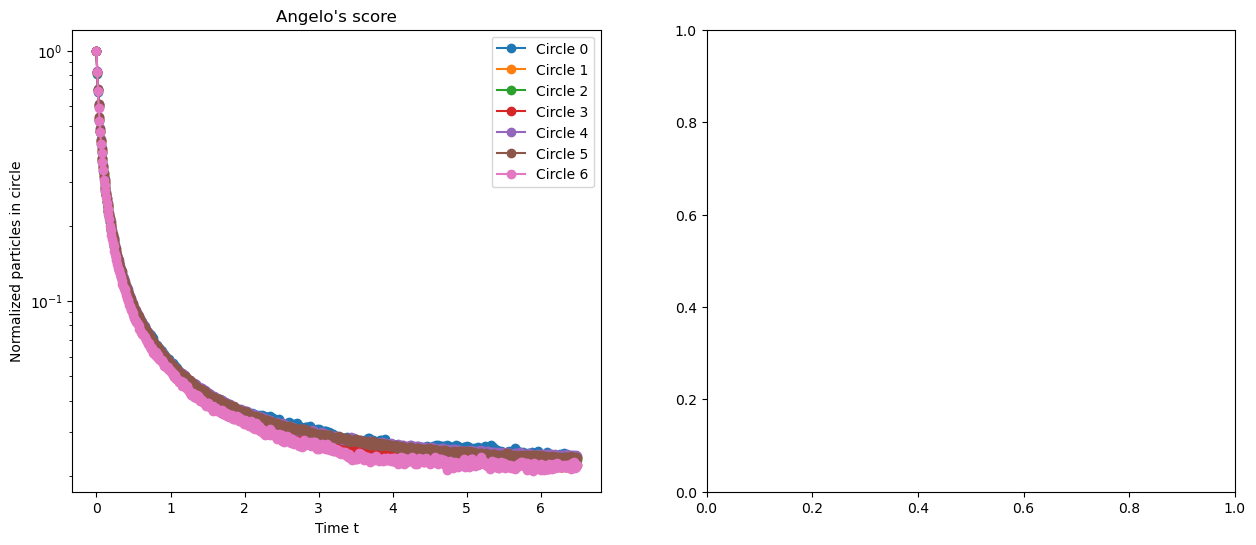

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6))

timeRange = np.arange(num_steps) * dt

# Trajectory
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 0], 'o-', label='Circle 0')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 1], 'o-', label='Circle 1')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 2], 'o-', label='Circle 2')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 3], 'o-', label='Circle 3')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 4], 'o-', label='Circle 4')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 5], 'o-', label='Circle 5')
axes[0].plot(timeRange, particlesPerCircleNormalized1[:, 6], 'o-', label='Circle 6')
axes[0].legend()
axes[0].set_xlabel('Time t')
axes[0].set_ylabel('Normalized particles in circle')
axes[0].set_title("Angelo's score")

# axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 0], 'o-', label='Circle 0')
# axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 1], 'o-', label='Circle 1')
# axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 2], 'o-', label='Circle 2')
# axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 3], 'o-', label='Circle 3')
# axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 4], 'o-', label='Circle 4')
# axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 5], 'o-', label='Circle 5')
# axes[1].plot(timeRange, particlesPerCircleNormalized2[:, 6], 'o-', label='Circle 6')
# axes[1].legend()
# axes[1].set_xlabel('Time t')
# axes[1].set_ylabel('Normalized particles in circle')
# axes[1].set_title("Klaas' score")
plt.savefig("massVsTime.pdf")

plt.show()
